In [5]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
%autoreload 2

In [7]:
from harp.data.collect import collect
from harp.data.process import clean_df, group_by_reviewer, inject_rejected

import pandas as pd
from sklearn.model_selection import train_test_split
import os

In [8]:
collect(5, "data/raw/samples")
clean_df(pd.read_csv("harp/data/raw/cms_2008_2010_samples.csv"))
group_by_reviewer(pd.read_csv("harp/data/raw/cms_2008_2010_samples_cleaned.csv"))

Initial size: 332606
Final clean size: 326651


In [9]:
df = pd.read_csv("harp/data/raw/csm_2008_2010_samples_grouped.csv")

RANDOM_STATE = 42

df_train_val, df_test = train_test_split(
    df, 
    test_size=0.15, 
    random_state=RANDOM_STATE,
    shuffle=True
)

validation_size = 0.15 / 0.85
df_train, df_val = train_test_split(
    df_train_val, 
    test_size=validation_size, 
    random_state=RANDOM_STATE,
    shuffle=True
)

df_train = inject_rejected(df_train, 0.2)
df_val = inject_rejected(df_val, 0.2)
df_test = inject_rejected(df_test, 0.2)

os.makedirs("harp/data/raw/harp_dataset")
df_train.to_csv("harp/data/raw/harp_dataset/train.csv", index=False)
df_val.to_csv("harp/data/raw/harp_dataset/val.csv", index=False)
df_test.to_csv("harp/data/raw/harp_dataset/test.csv", index=False)

Dataset Overview
Training set: 274,386 rows
Validation set: 58,797 rows
Test set: 58,797 rows
Total: 391,980 rows

Training Set - Shape and Data Types
Shape: (274386, 36)

Columns (36):
   1. DESYNPUF_ID                              (object)
   2. CLM_ID                                   (int64)
   3. PRVDR_NUM                                (object)
   4. AT_PHYSN_NPI                             (object)
   5. CLM_ADMSN_DT                             (int64)
   6. NCH_BENE_DSCHRG_DT                       (int64)
   7. CLM_PMT_AMT                              (float64)
   8. CLM_DRG_CD                               (object)
   9. ADMTNG_ICD9_DGNS_CD                      (object)
  10. CLM_UTLZTN_DAY_CNT                       (float64)
  11. OP_PHYSN_NPI                             (object)
  12. ICD9_DGNS_CD_1                           (object)
  13. ICD9_DGNS_CD_2                           (object)
  14. ICD9_DGNS_CD_3                           (object)
  15. ICD9_DGNS_CD_4           

,DESYNPUF_ID,CLM_ID,PRVDR_NUM,AT_PHYSN_NPI,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_PMT_AMT,CLM_DRG_CD,ADMTNG_ICD9_DGNS_CD,CLM_UTLZTN_DAY_CNT,OP_PHYSN_NPI,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,ICD9_PRCDR_CD_4,ICD9_PRCDR_CD_5,ICD9_PRCDR_CD_6,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,reviewer_score,reviewer,reviewer_reasons,claim_status,rejection_reason_code,rejection_desc
0,1795FF45112F15B1,744061196224021,23006G,MISSING,20090609,20090701,17000.0,939,V5789,22.0,NONE,V5789,V4364,78072,34982,78097,43820,V5832,V4511,43822,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1068.0,0.0,2,2,['Surgical'],0,missing_physician,Missing Attending Physician NPI
1,0F8A99175C13F37F,744561196222506,34S0YJ,4244422737.0,20081226,20081228,6000.0,872,56211,2.0,NONE,03843,57420,3310,27651,74687,42731,04111,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,0.0,0.0,2,2,['Surgical'],1,None,Accepted
2,F005B7C124E5AAEF,196961176958797,2100NQ,2241050583.0,20080219,20080223,7000.0,566,8082,4.0,2241050583.0,8082,59970,2760,4019,4280,41071,86803,9998,486,NONE,3995.0,NONE,NONE,NONE,NONE,NONE,0.0,1024.0,0.0,2,2,['Surgical'],1,None,Accepted
3,CD7CD547AF84C7F6,895861123132565,3013SA,128268716.0,20090405,20090406,4000.0,478,72210,1.0,128268716.0,72402,53081,V454,V4365,NONE,NONE,NONE,NONE,NONE,NONE,309.0,NONE,NONE,NONE,NONE,NONE,0.0,1068.0,0.0,5,3,"['Short-Stay', 'Surgical']",1,None,Accepted
4,091EE4F21838599F,744751196207290,3101AB,4029684953.0,20080330,20080401,4000.0,065,78720,2.0,NONE,3501,42731,2809,5180,V5869,7960,3510,2724,V123,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1024.0,0.0,2,2,['Surgical'],1,None,Accepted



Training Set - Sample rows (showing all columns)


,DESYNPUF_ID,CLM_ID,PRVDR_NUM,AT_PHYSN_NPI,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_PMT_AMT,CLM_DRG_CD,ADMTNG_ICD9_DGNS_CD,CLM_UTLZTN_DAY_CNT,OP_PHYSN_NPI,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,ICD9_PRCDR_CD_4,ICD9_PRCDR_CD_5,ICD9_PRCDR_CD_6,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,reviewer_score,reviewer,reviewer_reasons,claim_status,rejection_reason_code,rejection_desc
60082,205B1BB7AD7C99AA,744041196262918,0503NV,3867083193.0,20080719,20080720,21000.0,216,4111,1.0,3692509901.0,41071,41412,42823,49390,V1582,41402,28860,V173,5849,NONE,66.0,NONE,4019,41402,5990,41011,0.0,0.0,0.0,6,3,"['Short-Stay', 'Surgical', 'High-Cost']",1,None,Accepted
154073,9EBD1D0BCA039A60,895131123120247,1000VV,7124974092.0,20090929,20091004,7000.0,MISSING,45341,5.0,NONE,45351,99681,V138,25000,4019,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1068.0,0.0,2,2,['Surgical'],0,missing_drg,Claim submitted without DRG Code
24466,D4820A6D2360E06F,895471123155038,3600CS,5333645593.0,20080520,20080529,25000.0,384,56211,9.0,5333645593.0,1536,V160,4019,56400,2720,4280,42789,9982,1976,NONE,4573.0,73300,29530,5601,NONE,NONE,0.0,1024.0,0.0,3,2,"['Surgical', 'High-Cost']",1,None,Accepted



Training Set - Basic Statistics


,CLM_ID,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_PMT_AMT,CLM_UTLZTN_DAY_CNT,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,reviewer_score,reviewer,claim_status
count,2.743860e+05,2.743860e+05,2.743860e+05,274386.000000,274386.000000,274386.000000,274386.000000,274386.000000,274386.000000,274386.000000,274386.000000
mean,4.951710e+14,2.008851e+07,2.008863e+07,9388.519968,5.344270,431.239932,1093.814757,85.979241,2.619992,2.173504,0.833333
std,3.236278e+14,7.584845e+03,7.561835e+03,9199.911064,6.129727,3929.883101,556.601001,969.112783,1.194602,0.378683,0.372679
min,4.501115e+13,2.007113e+07,2.007071e+07,-8000.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
25%,1.962512e+14,2.008082e+07,2.008082e+07,4000.000000,2.000000,0.000000,1024.000000,0.000000,2.000000,2.000000,1.000000
50%,5.945012e+14,2.009032e+07,2.009032e+07,7000.000000,4.000000,0.000000,1068.000000,0.000000,2.000000,2.000000,1.000000
75%,7.447512e+14,2.009111e+07,2.009112e+07,11000.000000,6.000000,0.000000,1068.000000,0.000000,3.000000,2.000000,1.000000
max,8.959911e+14,2.010123e+07,2.010123e+07,57000.000000,142.000000,68000.000000,5000.000000,34000.000000,9.000000,3.000000,1.000000



Training Set - Missing Values
No missing values!

Data Visualizations


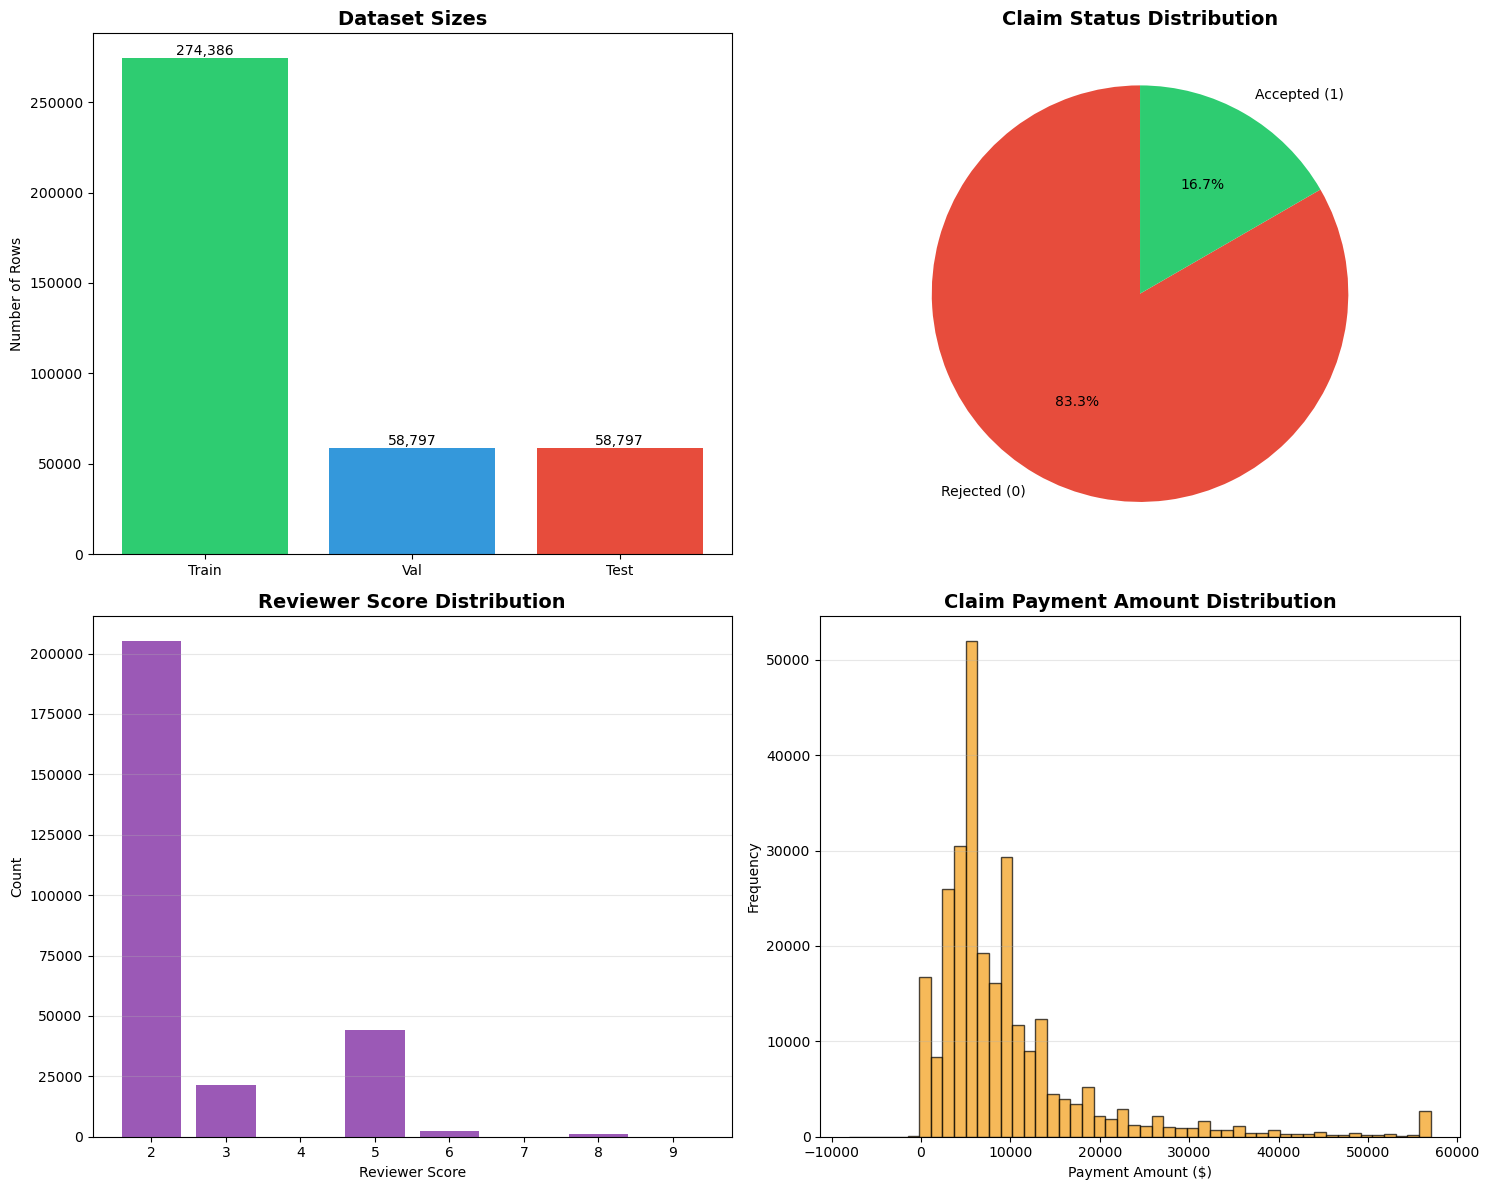


Key Statistics
Average claim payment: $9,388.52
Median claim payment: $7,000.00
Average utilization days: 5.34
Average reviewer score: 2.62
Acceptance rate: 83.33%
Number of unique reviewers: 2
Number of unique claims: 228655


In [11]:
# Configure pandas to display all columns and rows
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Load and view the training datasets
train_df = pd.read_csv("harp/data/raw/harp_dataset/train.csv")
val_df = pd.read_csv("harp/data/raw/harp_dataset/val.csv")
test_df = pd.read_csv("harp/data/raw/harp_dataset/test.csv")

print("=" * 80)
print("Dataset Overview")
print("=" * 80)
print(f"Training set: {len(train_df):,} rows")
print(f"Validation set: {len(val_df):,} rows")
print(f"Test set: {len(test_df):,} rows")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,} rows")
print()

print("=" * 80)
print("Training Set - Shape and Data Types")
print("=" * 80)
print(f"Shape: {train_df.shape}")
print(f"\nColumns ({len(train_df.columns)}):")
for i, col in enumerate(train_df.columns, 1):
    print(f"  {i:2d}. {col:40s} ({train_df[col].dtype})")
print()

print("=" * 80)
print("Training Set - First 5 rows (ALL COLUMNS)")
print("=" * 80)
display(train_df.head())
print()

print("=" * 80)
print("Training Set - Sample rows (showing all columns)")
print("=" * 80)
display(train_df.sample(3))
print()

print("=" * 80)
print("Training Set - Basic Statistics")
print("=" * 80)
display(train_df.describe())
print()

print("=" * 80)
print("Training Set - Missing Values")
print("=" * 80)
missing = train_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    display(missing)
else:
    print("No missing values!")
print()

# Visualizations
print("=" * 80)
print("Data Visualizations")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Dataset size comparison
axes[0, 0].bar(['Train', 'Val', 'Test'], 
               [len(train_df), len(val_df), len(test_df)],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 0].set_title('Dataset Sizes', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Rows')
for i, v in enumerate([len(train_df), len(val_df), len(test_df)]):
    axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 2. Claim status distribution
claim_status_counts = train_df['claim_status'].value_counts()
axes[0, 1].pie(claim_status_counts.values, 
               labels=['Rejected (0)', 'Accepted (1)'],
               autopct='%1.1f%%',
               colors=['#e74c3c', '#2ecc71'],
               startangle=90)
axes[0, 1].set_title('Claim Status Distribution', fontsize=14, fontweight='bold')

# 3. Reviewer score distribution
reviewer_scores = train_df['reviewer_score'].value_counts().sort_index()
axes[1, 0].bar(reviewer_scores.index, reviewer_scores.values, color='#9b59b6')
axes[1, 0].set_title('Reviewer Score Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Reviewer Score')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Claim payment amount distribution (log scale for better visualization)
axes[1, 1].hist(train_df['CLM_PMT_AMT'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Claim Payment Amount Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Payment Amount ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional statistics
print("\n" + "=" * 80)
print("Key Statistics")
print("=" * 80)
print(f"Average claim payment: ${train_df['CLM_PMT_AMT'].mean():,.2f}")
print(f"Median claim payment: ${train_df['CLM_PMT_AMT'].median():,.2f}")
print(f"Average utilization days: {train_df['CLM_UTLZTN_DAY_CNT'].mean():.2f}")
print(f"Average reviewer score: {train_df['reviewer_score'].mean():.2f}")
print(f"Acceptance rate: {train_df['claim_status'].mean()*100:.2f}%")
print(f"Number of unique reviewers: {train_df['reviewer'].nunique()}")
print(f"Number of unique claims: {train_df['CLM_ID'].nunique()}")


In [14]:
# ============================================================================
# CHECK FOR "MISSING" VALUES IN ALL COLUMNS
# ============================================================================
# This cell identifies which columns contain the string "missing" or "MISSING"
# These are placeholder values used to indicate missing data in categorical columns

print("=" * 80)
print("CHECKING FOR 'MISSING' VALUES IN ALL COLUMNS")
print("=" * 80)
print()

# Dictionary to store results
columns_with_missing = {}

# Check each column for "missing" or "MISSING" (case-insensitive)
for col in train_df.columns:
    # Only check object/string columns (numerical columns won't have "MISSING" strings)
    if train_df[col].dtype == 'object':
        # Convert to string and check for "MISSING" (case-insensitive)
        missing_mask = train_df[col].astype(str).str.upper().str.contains('MISSING', na=False)
        missing_count = missing_mask.sum()
        
        if missing_count > 0:
            # Get unique values that contain "MISSING" to see the exact format
            missing_values = train_df[missing_mask][col].unique()
            columns_with_missing[col] = {
                'count': missing_count,
                'percentage': (missing_count / len(train_df)) * 100,
                'sample_values': missing_values[:5].tolist()  # Show up to 5 sample values
            }

# Display results
if columns_with_missing:
    print(f"Found {len(columns_with_missing)} column(s) containing 'MISSING' values:\n")
    
    for col, info in columns_with_missing.items():
        print(f"Column: {col}")
        print(f"  - Count: {info['count']:,} ({info['percentage']:.2f}% of rows)")
        print(f"  - Sample values: {info['sample_values']}")
        print()
    
    # Create a summary DataFrame
    missing_summary = pd.DataFrame({
        'Column': list(columns_with_missing.keys()),
        'Count': [info['count'] for info in columns_with_missing.values()],
        'Percentage': [info['percentage'] for info in columns_with_missing.values()],
        'Sample_Values': [', '.join(map(str, info['sample_values'])) for info in columns_with_missing.values()]
    }).sort_values('Count', ascending=False)
    
    print("=" * 80)
    print("SUMMARY TABLE")
    print("=" * 80)
    display(missing_summary)
    
    # Show some example rows with missing values
    print("\n" + "=" * 80)
    print("EXAMPLE ROWS WITH 'MISSING' VALUES")
    print("=" * 80)
    
    for col in list(columns_with_missing.keys())[:3]:  # Show examples for first 3 columns
        missing_mask = train_df[col].astype(str).str.upper().str.contains('MISSING', na=False)
        if missing_mask.sum() > 0:
            print(f"\nSample rows where '{col}' contains 'MISSING':")
            sample_rows = train_df[missing_mask].head(3)
            # Show relevant columns
            relevant_cols = [col, 'reviewer', 'reviewer_score', 'claim_status']
            relevant_cols = [c for c in relevant_cols if c in train_df.columns]
            display(sample_rows[relevant_cols])
    
else:
    print("No columns found containing 'MISSING' values!")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


CHECKING FOR 'MISSING' VALUES IN ALL COLUMNS

Found 4 column(s) containing 'MISSING' values:

Column: AT_PHYSN_NPI
  - Count: 10,672 (3.89% of rows)
  - Sample values: ['MISSING']

Column: CLM_DRG_CD
  - Count: 5,396 (1.97% of rows)
  - Sample values: ['MISSING']

Column: rejection_reason_code
  - Count: 16,068 (5.86% of rows)
  - Sample values: ['missing_physician', 'missing_drg']

Column: rejection_desc
  - Count: 16,928 (6.17% of rows)
  - Sample values: ['Missing Attending Physician NPI', 'Invalid or Missing Admitting Diagnosis Code']

SUMMARY TABLE


,Column,Count,Percentage,Sample_Values
3,rejection_desc,16928,6.169411,"Missing Attending Physician NPI, Invalid or Mi..."
2,rejection_reason_code,16068,5.855984,"missing_physician, missing_drg"
0,AT_PHYSN_NPI,10672,3.889411,MISSING
1,CLM_DRG_CD,5396,1.966573,MISSING



EXAMPLE ROWS WITH 'MISSING' VALUES

Sample rows where 'AT_PHYSN_NPI' contains 'MISSING':


,AT_PHYSN_NPI,reviewer,reviewer_score,claim_status
0,MISSING,2,2,0
9,MISSING,2,2,0
15,MISSING,3,5,0



Sample rows where 'CLM_DRG_CD' contains 'MISSING':


,CLM_DRG_CD,reviewer,reviewer_score,claim_status
20,MISSING,2,3,0
45,MISSING,2,2,0
103,MISSING,2,2,0



Sample rows where 'rejection_reason_code' contains 'MISSING':


,rejection_reason_code,reviewer,reviewer_score,claim_status
0,missing_physician,2,2,0
9,missing_physician,2,2,0
15,missing_physician,3,5,0



ANALYSIS COMPLETE


FEATURE IMPORTANCE ANALYSIS FOR reviewer_score

1. CORRELATION ANALYSIS (Numerical Features)
--------------------------------------------------------------------------------
Top 10 Numerical Features by Correlation:


,Column,Abs_Correlation
0,NCH_PRMRY_PYR_CLM_PD_AMT,0.281483
1,CLM_UTLZTN_DAY_CNT,0.230503
2,CLM_PMT_AMT,0.105335
3,CLM_ADMSN_DT,0.009498
4,NCH_BENE_IP_DDCTBL_AMT,0.007250
5,NCH_BENE_DSCHRG_DT,0.005837
6,NCH_BENE_PTA_COINSRNC_LBLTY_AM,0.002311
7,CLM_ID,0.002039



2. ANOVA F-TEST (Categorical Features)
--------------------------------------------------------------------------------
Top 10 Categorical Features by F-Statistic:


,Column,F_Statistic
0,ICD9_PRCDR_CD_1,11.345598
1,CLM_DRG_CD,10.756270
2,ICD9_DGNS_CD_1,6.551117
3,ADMTNG_ICD9_DGNS_CD,6.100624
4,ICD9_DGNS_CD_8,2.510516
5,ICD9_DGNS_CD_9,2.484454
6,ICD9_DGNS_CD_7,2.396135
7,ICD9_DGNS_CD_6,2.282897
8,ICD9_DGNS_CD_5,2.242662
9,ICD9_PRCDR_CD_6,2.160938



3. MUTUAL INFORMATION ANALYSIS
--------------------------------------------------------------------------------
Top 10 Features by Mutual Information:


...


5. COMBINED FEATURE IMPORTANCE RANKING
--------------------------------------------------------------------------------
ALL FEATURES RANKED BY COMBINED IMPORTANCE:


,Column,Combined_Score
0,CLM_UTLZTN_DAY_CNT,0.939630
1,ICD9_PRCDR_CD_1,0.471963
2,NCH_PRMRY_PYR_CLM_PD_AMT,0.469916
3,CLM_PMT_AMT,0.469573
4,CLM_DRG_CD,0.356632
5,ICD9_DGNS_CD_1,0.285524
6,ADMTNG_ICD9_DGNS_CD,0.248278
7,ICD9_DGNS_CD_9,0.118417
8,ICD9_DGNS_CD_8,0.114280
9,ICD9_DGNS_CD_7,0.109792



6. COLUMNS WITH LOWEST IMPACT ON reviewer_score

Columns with Combined Score <= 0.0449 (Bottom 20%):
Total: 6 columns



,Column,Combined_Score,Data_Type,Unique_Values,Missing_Values,F_Statistic,Mutual_Info,RF_Importance,Correlation
5,NCH_BENE_PTA_COINSRNC_LBLTY_AM,0.004054,float64,39,0,NaN,0.001229,0.000054,0.002311
4,CLM_ID,0.006094,int64,228655,0,NaN,0.003385,0.000259,0.002039
3,NCH_BENE_DSCHRG_DT,0.007751,int64,1574,0,NaN,0.000723,0.000171,0.005837
2,NCH_BENE_IP_DDCTBL_AMT,0.009631,float64,5,0,NaN,0.000722,0.000627,0.007250
1,CLM_ADMSN_DT,0.015916,int64,1127,0,NaN,0.004320,0.000271,0.009498
0,ICD9_DGNS_CD_10,0.041882,object,1952,0,1.131035,0.008186,0.000088,NaN



7. VISUALIZATIONS


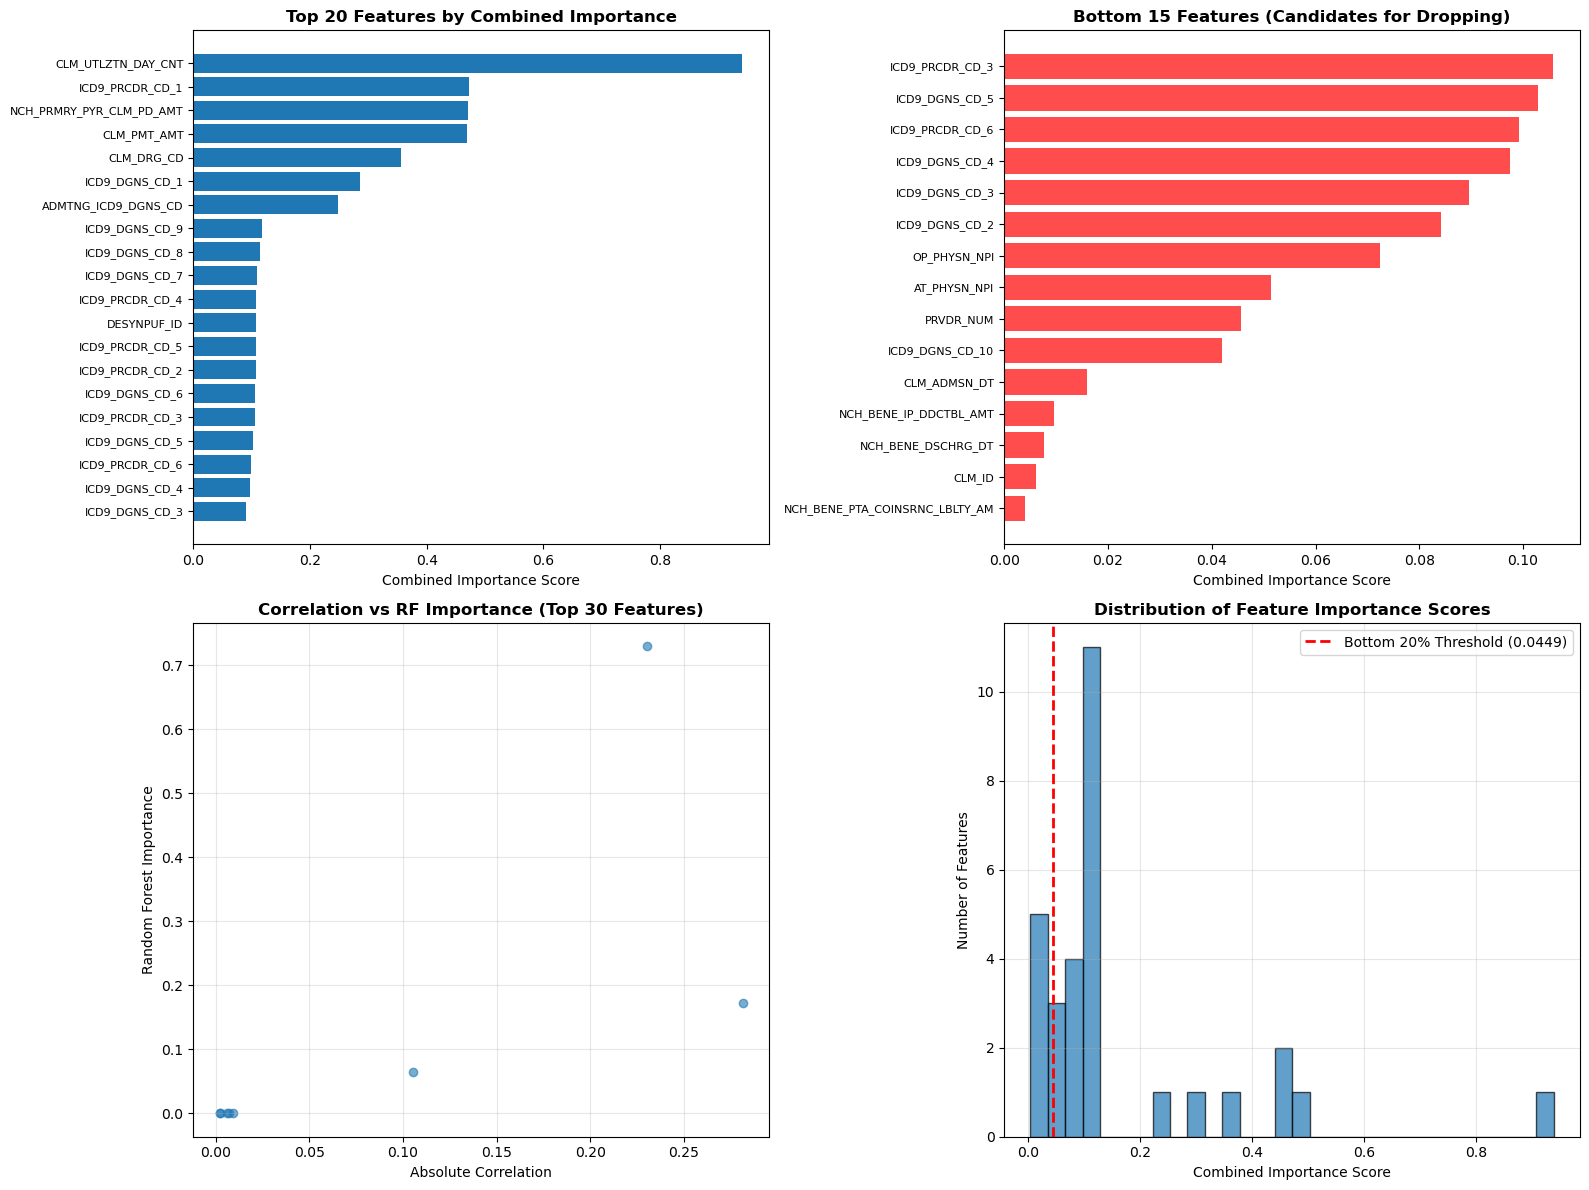


8. SUMMARY AND RECOMMENDATIONS

Total features analyzed: 30
Features with low impact (bottom 20%): 6

RECOMMENDED COLUMNS TO DROP (Lowest Impact):
--------------------------------------------------------------------------------

NCH_BENE_PTA_COINSRNC_LBLTY_AM:
  - Combined Score: 0.004054
  - Data Type: float64
  - Unique Values: 39
  - Correlation: 0.002311
  - RF Importance: 0.000054

CLM_ID:
  - Combined Score: 0.006094
  - Data Type: int64
  - Unique Values: 228655
  - Correlation: 0.002039
  - RF Importance: 0.000259

NCH_BENE_DSCHRG_DT:
  - Combined Score: 0.007751
  - Data Type: int64
  - Unique Values: 1574
  - Correlation: 0.005837
  - RF Importance: 0.000171

NCH_BENE_IP_DDCTBL_AMT:
  - Combined Score: 0.009631
  - Data Type: float64
  - Unique Values: 5
  - Correlation: 0.007250
  - RF Importance: 0.000627

CLM_ADMSN_DT:
  - Combined Score: 0.015916
  - Data Type: int64
  - Unique Values: 1127
  - Correlation: 0.009498
  - RF Importance: 0.000271

ICD9_DGNS_CD_10:
  - Combi

In [15]:
# ============================================================================
# COMPREHENSIVE EDA: Identifying columns with least impact on reviewer_score
# ============================================================================

from scipy import stats
from scipy.stats import f_oneway
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS FOR reviewer_score")
print("=" * 80)
print()

# Separate target variable
target = 'reviewer_score'
y = train_df[target]

# Prepare results storage
results = []

# ============================================================================
# 1. CORRELATION ANALYSIS (for numerical columns)
# ============================================================================
print("1. CORRELATION ANALYSIS (Numerical Features)")
print("-" * 80)

numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target and derived columns
numerical_cols = [col for col in numerical_cols if col not in [target, 'reviewer', 'claim_status']]

correlations = {}
for col in numerical_cols:
    corr = train_df[col].corr(y)
    correlations[col] = abs(corr)  # Use absolute correlation
    results.append({
        'Column': col,
        'Type': 'Numerical',
        'Correlation': corr,
        'Abs_Correlation': abs(corr),
        'Method': 'Pearson Correlation'
    })

corr_df = pd.DataFrame(sorted(correlations.items(), key=lambda x: x[1], reverse=True), 
                       columns=['Column', 'Abs_Correlation'])
print("Top 10 Numerical Features by Correlation:")
display(corr_df.head(10))
print()

# ============================================================================
# 2. ANOVA F-TEST (for categorical columns)
# ============================================================================
print("2. ANOVA F-TEST (Categorical Features)")
print("-" * 80)

categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
# Remove derived columns
categorical_cols = [col for col in categorical_cols if col not in ['reviewer_reasons', 'rejection_reason_code', 'rejection_desc']]

f_scores = {}
for col in categorical_cols:
    try:
        # Group by category and get reviewer_score for each group
        groups = [group[target].values for name, group in train_df.groupby(col)]
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            f_stat, p_value = f_oneway(*groups)
            f_scores[col] = f_stat
            results.append({
                'Column': col,
                'Type': 'Categorical',
                'F_Statistic': f_stat,
                'P_Value': p_value,
                'Method': 'ANOVA F-Test'
            })
    except:
        pass

if f_scores:
    f_df = pd.DataFrame(sorted(f_scores.items(), key=lambda x: x[1], reverse=True), 
                        columns=['Column', 'F_Statistic'])
    print("Top 10 Categorical Features by F-Statistic:")
    display(f_df.head(10))
    print()

# ============================================================================
# 3. MUTUAL INFORMATION
# ============================================================================
print("3. MUTUAL INFORMATION ANALYSIS")
print("-" * 80)

# Prepare data for mutual information
X_mi = train_df.drop(columns=[target, 'reviewer', 'claim_status', 'reviewer_reasons', 
                              'rejection_reason_code', 'rejection_desc'], errors='ignore')

# Encode categorical variables
X_mi_encoded = X_mi.copy()
label_encoders = {}
for col in X_mi_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_mi_encoded[col] = le.fit_transform(X_mi_encoded[col].astype(str))
    label_encoders[col] = le

# Calculate mutual information
mi_scores = mutual_info_regression(X_mi_encoded, y, random_state=42)
mi_df = pd.DataFrame({
    'Column': X_mi_encoded.columns,
    'Mutual_Information': mi_scores
}).sort_values('Mutual_Information', ascending=False)

print("Top 10 Features by Mutual Information:")
display(mi_df.head(10))
print()

# Add to results
for idx, row in mi_df.iterrows():
    results.append({
        'Column': row['Column'],
        'Type': 'Mixed',
        'Mutual_Information': row['Mutual_Information'],
        'Method': 'Mutual Information'
    })

# ============================================================================
# 4. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================
print("4. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 80)

# Prepare data
X_rf = X_mi_encoded.copy()

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_rf, y)

# Get feature importance
rf_importance = pd.DataFrame({
    'Column': X_rf.columns,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("Top 10 Features by Random Forest Importance:")
display(rf_importance.head(10))
print()

# Add to results
for idx, row in rf_importance.iterrows():
    results.append({
        'Column': row['Column'],
        'Type': 'Mixed',
        'RF_Importance': row['RF_Importance'],
        'Method': 'Random Forest'
    })

# ============================================================================
# 5. COMBINED RANKING
# ============================================================================
print("5. COMBINED FEATURE IMPORTANCE RANKING")
print("-" * 80)

# First, collect all scores globally to find max values for normalization
all_columns = set()
for r in results:
    all_columns.add(r['Column'])

# Collect all scores by type globally
global_scores = {
    'corr': [],
    'f_stat': [],
    'mi': [],
    'rf': []
}

for col in all_columns:
    # Get correlation score
    corr_data = [r for r in results if r['Column'] == col and 'Abs_Correlation' in r]
    if corr_data:
        global_scores['corr'].append(corr_data[0]['Abs_Correlation'])
    
    # Get F-statistic
    f_data = [r for r in results if r['Column'] == col and 'F_Statistic' in r]
    if f_data:
        global_scores['f_stat'].append(f_data[0]['F_Statistic'])
    
    # Get mutual information
    mi_data = [r for r in results if r['Column'] == col and 'Mutual_Information' in r]
    if mi_data:
        global_scores['mi'].append(mi_data[0]['Mutual_Information'])
    
    # Get RF importance
    rf_data = [r for r in results if r['Column'] == col and 'RF_Importance' in r]
    if rf_data:
        global_scores['rf'].append(rf_data[0]['RF_Importance'])

# Find global max for each score type
global_max = {}
for score_type, score_list in global_scores.items():
    global_max[score_type] = max(score_list) if score_list and max(score_list) > 0 else 1.0

# Now normalize and combine scores
combined_scores = {}
for col in all_columns:
    normalized_scores = []
    
    # Get correlation score
    corr_data = [r for r in results if r['Column'] == col and 'Abs_Correlation' in r]
    if corr_data:
        normalized = corr_data[0]['Abs_Correlation'] / global_max['corr']
        normalized_scores.append(normalized)
    
    # Get F-statistic
    f_data = [r for r in results if r['Column'] == col and 'F_Statistic' in r]
    if f_data:
        normalized = f_data[0]['F_Statistic'] / global_max['f_stat']
        normalized_scores.append(normalized)
    
    # Get mutual information
    mi_data = [r for r in results if r['Column'] == col and 'Mutual_Information' in r]
    if mi_data:
        normalized = mi_data[0]['Mutual_Information'] / global_max['mi']
        normalized_scores.append(normalized)
    
    # Get RF importance
    rf_data = [r for r in results if r['Column'] == col and 'RF_Importance' in r]
    if rf_data:
        normalized = rf_data[0]['RF_Importance'] / global_max['rf']
        normalized_scores.append(normalized)
    
    # Average normalized scores
    combined_scores[col] = np.mean(normalized_scores) if normalized_scores else 0

# Create combined ranking
combined_df = pd.DataFrame(sorted(combined_scores.items(), key=lambda x: x[1], reverse=True),
                          columns=['Column', 'Combined_Score'])

print("ALL FEATURES RANKED BY COMBINED IMPORTANCE:")
print("=" * 80)
display(combined_df)

# ============================================================================
# 6. IDENTIFY LOW IMPACT COLUMNS (Candidates for Dropping)
# ============================================================================
print("\n" + "=" * 80)
print("6. COLUMNS WITH LOWEST IMPACT ON reviewer_score")
print("=" * 80)

# Define threshold (bottom 20% of features)
threshold = np.percentile(combined_df['Combined_Score'], 20)
low_impact = combined_df[combined_df['Combined_Score'] <= threshold].copy()

print(f"\nColumns with Combined Score <= {threshold:.4f} (Bottom 20%):")
print(f"Total: {len(low_impact)} columns")
print()

# Show detailed breakdown for low impact columns
low_impact_details = []
for col in low_impact['Column']:
    col_info = {
        'Column': col,
        'Combined_Score': combined_df[combined_df['Column'] == col]['Combined_Score'].values[0],
        'Data_Type': train_df[col].dtype,
        'Unique_Values': train_df[col].nunique(),
        'Missing_Values': train_df[col].isnull().sum()
    }
    
    # Add method-specific scores
    corr_data = [r for r in results if r['Column'] == col and 'Abs_Correlation' in r]
    if corr_data:
        col_info['Correlation'] = corr_data[0]['Abs_Correlation']
    
    f_data = [r for r in results if r['Column'] == col and 'F_Statistic' in r]
    if f_data:
        col_info['F_Statistic'] = f_data[0]['F_Statistic']
    
    mi_data = [r for r in results if r['Column'] == col and 'Mutual_Information' in r]
    if mi_data:
        col_info['Mutual_Info'] = mi_data[0]['Mutual_Information']
    
    rf_data = [r for r in results if r['Column'] == col and 'RF_Importance' in r]
    if rf_data:
        col_info['RF_Importance'] = rf_data[0]['RF_Importance']
    
    low_impact_details.append(col_info)

low_impact_df = pd.DataFrame(low_impact_details)
display(low_impact_df.sort_values('Combined_Score'))

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("7. VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Combined importance scores
top_n = 20
top_features = combined_df.head(top_n)
axes[0, 0].barh(range(len(top_features)), top_features['Combined_Score'].values)
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['Column'].values, fontsize=8)
axes[0, 0].set_xlabel('Combined Importance Score')
axes[0, 0].set_title(f'Top {top_n} Features by Combined Importance', fontweight='bold')
axes[0, 0].invert_yaxis()

# Plot 2: Bottom features
bottom_n = 15
bottom_features = combined_df.tail(bottom_n)
axes[0, 1].barh(range(len(bottom_features)), bottom_features['Combined_Score'].values, color='red', alpha=0.7)
axes[0, 1].set_yticks(range(len(bottom_features)))
axes[0, 1].set_yticklabels(bottom_features['Column'].values, fontsize=8)
axes[0, 1].set_xlabel('Combined Importance Score')
axes[0, 1].set_title(f'Bottom {bottom_n} Features (Candidates for Dropping)', fontweight='bold')
axes[0, 1].invert_yaxis()

# Plot 3: Correlation vs RF Importance (scatter)
corr_scores = []
rf_scores = []
feature_names = []
for col in combined_df['Column'].head(30):
    corr_data = [r for r in results if r['Column'] == col and 'Abs_Correlation' in r]
    rf_data = [r for r in results if r['Column'] == col and 'RF_Importance' in r]
    if corr_data and rf_data:
        corr_scores.append(corr_data[0]['Abs_Correlation'])
        rf_scores.append(rf_data[0]['RF_Importance'])
        feature_names.append(col)

if corr_scores:
    axes[1, 0].scatter(corr_scores, rf_scores, alpha=0.6)
    axes[1, 0].set_xlabel('Absolute Correlation')
    axes[1, 0].set_ylabel('Random Forest Importance')
    axes[1, 0].set_title('Correlation vs RF Importance (Top 30 Features)', fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

# Plot 4: Distribution of combined scores
axes[1, 1].hist(combined_df['Combined_Score'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Bottom 20% Threshold ({threshold:.4f})')
axes[1, 1].set_xlabel('Combined Importance Score')
axes[1, 1].set_ylabel('Number of Features')
axes[1, 1].set_title('Distribution of Feature Importance Scores', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("8. SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

print(f"\nTotal features analyzed: {len(combined_df)}")
print(f"Features with low impact (bottom 20%): {len(low_impact)}")
print(f"\nRECOMMENDED COLUMNS TO DROP (Lowest Impact):")
print("-" * 80)

# Show top candidates for dropping
drop_candidates = low_impact_df.sort_values('Combined_Score').head(10)
for idx, row in drop_candidates.iterrows():
    print(f"\n{row['Column']}:")
    print(f"  - Combined Score: {row['Combined_Score']:.6f}")
    print(f"  - Data Type: {row['Data_Type']}")
    print(f"  - Unique Values: {row['Unique_Values']}")
    if 'Correlation' in row and pd.notna(row['Correlation']):
        print(f"  - Correlation: {row['Correlation']:.6f}")
    if 'RF_Importance' in row and pd.notna(row['RF_Importance']):
        print(f"  - RF Importance: {row['RF_Importance']:.6f}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)


In [22]:
import pandas as pd 
from harp.data.process import encode
test_data = pd.read_csv('/Users/lagnajeetpanigrahi/Desktop/Harp-Project/harp/harp/data/raw/harp_dataset/test.csv')
new_data = encode(test_data)
new_data

,CLM_PMT_AMT,CLM_DRG_CD,ADMTNG_ICD9_DGNS_CD,CLM_UTLZTN_DAY_CNT,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,ICD9_PRCDR_CD_4,ICD9_PRCDR_CD_5,ICD9_PRCDR_CD_6,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,reviewer,claim_status
0,4000.0,653,78097,4.0,5990,27651,4019,28529,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1068.0,0.0,2,1
1,3000.0,187,49121,5.0,486,73300,2948,27800,3331,42731,60000,53081,V141,NONE,9921.0,4019,78605,79902,496,V5861,0.0,1100.0,0.0,2,1
2,5000.0,166,5990,4.0,49122,53081,486,V1582,7866,42731,5849,4019,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1024.0,0.0,2,1
3,11000.0,304,41401,2.0,41401,V1254,4019,4111,4240,2809,42789,25000,4139,NONE,66.0,V4581,3051,2724,41401,4019,0.0,1068.0,0.0,2,1
4,1000.0,175,78605,7.0,78652,4019,5723,78609,V5866,71590,25000,2724,4168,NONE,9917.0,4439,2449,4019,NONE,NONE,0.0,1024.0,0.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58792,14000.0,513,73390,12.0,8054,V140,V426,2449,71590,4280,9986,1985,NONE,NONE,7745.0,V1011,NONE,NONE,NONE,NONE,0.0,1024.0,0.0,2,1
58793,32000.0,201,71945,17.0,99731,486,25000,71590,2763,51884,2762,2875,E9320,NONE,9672.0,4019,5849,5070,V551,496,0.0,1024.0,0.0,2,1
58794,2000.0,887,INVALID_999,4.0,29530,7960,71580,25002,30500,5853,30521,33390,4019,NONE,NONE,NONE,NONE,NONE,NONE,NONE,0.0,1024.0,0.0,2,0
58795,2000.0,906,9694,2.0,9663,5533,34590,30390,V1254,27401,2989,9713,78097,NONE,9396.0,NONE,NONE,NONE,NONE,NONE,0.0,1068.0,0.0,2,1


In [26]:
def replace(df, col, word, replacement):
     df[col] = df[col].replace(word, replacement)
     return df
     
def flag_non_numbers(df, col_name):
    """
    Returns all unique non-integer values in the specified column.
    
    Args:
        df: DataFrame
        col_name: Name of the column to check
        
    Returns:
        Array of unique non-integer values
    """
    # Convert to string and check if it's numeric (handles integers and floats)
    # A value is non-numeric if it can't be converted to a number
    def is_numeric(x):
        try:
            float(str(x))
            return True
        except (ValueError, TypeError):
            return False
    
    # Filter for non-numeric values and get unique values
    mask = ~df[col_name].apply(is_numeric)
    non_numeric_values = df.loc[mask, col_name]
    unique_values = non_numeric_values.unique()
    
    return unique_values
train_data = pd.read_csv('/Users/lagnajeetpanigrahi/Desktop/Harp-Project/harp/harp/data/raw/harp_dataset/train.csv')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_1')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_2')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_3')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_4')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_5')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_6')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_7')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_8')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_9')
flag_non_numbers(train_data, 'ICD9_DGNS_CD_10')


array(['NONE', 'E9359', 'E8844', 'V142', 'V850', 'E030', 'V103', 'V4364',
       'V4501', 'V148', 'V1582', 'V4582', 'V4511', 'V5861', 'V140',
       'V1251', 'E8781', 'V4581', 'V1254', 'E8859', 'V462', 'V1046',
       'V4589', 'E8786', 'E9378', 'V1259', 'E8889', 'E9352', 'V163',
       'V0481', 'E8120', 'E8788', 'V4365', 'E8580', 'E9309', 'V1851',
       'E8869', 'V4577', 'V8525', 'E9331', 'V6409', 'V5866', 'V433',
       'E0299', 'V4976', 'V1581', 'V422', 'V8801', 'E9363', 'E8809',
       'V153', 'V463', 'E9503', 'V551', 'E9444', 'V078', 'E8528', 'V8543',
       'V0382', 'E9342', 'E8888', 'V141', 'V4283', 'E9478', 'E9310',
       'V5867', 'V446', 'E8799', 'V8536', 'E9320', 'E9288', 'E9682',
       'V1204', 'E9504', 'V8534', 'V4975', 'E9387', 'E8780', 'V4282',
       'V1083', 'V667', 'E894', 'V1588', 'V8541', 'V1005', 'V1042',
       'E882', 'E8843', 'V146', 'E887', 'E9063', 'V441', 'V1051', 'V5878',
       'E8798', 'V1052', 'E9308', 'V5869', 'V0262', 'E856', 'V4611',
       'E8782', '

In [27]:
# Find all unique NON-INTEGER values (E codes, V codes, NONE, etc.) across specified columns
c = ['CLM_DRG_CD', 'ADMTNG_ICD9_DGNS_CD','ICD9_DGNS_CD_1', 'ICD9_DGNS_CD_2',
     'ICD9_DGNS_CD_3', 'ICD9_DGNS_CD_4', 'ICD9_DGNS_CD_5', 'ICD9_DGNS_CD_6',
     'ICD9_DGNS_CD_7', 'ICD9_DGNS_CD_8', 'ICD9_DGNS_CD_9', 'ICD9_DGNS_CD_10',
     'ICD9_PRCDR_CD_1', 'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3',
     'ICD9_PRCDR_CD_4', 'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6']

# Load the training data if not already loaded
if 'train_data' not in locals():
    train_data = pd.read_csv('/Users/lagnajeetpanigrahi/Desktop/Harp-Project/harp/harp/data/raw/harp_dataset/train.csv')

# Helper function to check if a value is numeric (integer or float)
def is_numeric(x):
    try:
        float(str(x))
        return True
    except (ValueError, TypeError):
        return False

# Collect all unique NON-INTEGER values from all specified columns
all_unique_values = set()

for col in c:
    if col in train_data.columns:
        # Get unique values from this column (excluding NaN)
        unique_vals = train_data[col].dropna().unique()
        # Filter out numeric values - only keep non-integer values
        non_numeric_vals = [val for val in unique_vals if not is_numeric(val)]
        # Add to the set (automatically handles duplicates)
        all_unique_values.update(non_numeric_vals)

# Custom sorting function: E codes first, then V codes, then NONE, then others
def sort_key(val):
    val_str = str(val).upper()
    if val_str.startswith('E'):
        return (0, val_str)  # E codes first
    elif val_str.startswith('V'):
        return (1, val_str)  # V codes second
    elif val_str == 'NONE':
        return (2, val_str)  # NONE third
    else:
        return (3, val_str)  # Everything else last

# Sort according to custom order
unique_array = sorted([str(val) for val in all_unique_values], key=sort_key)

print("=" * 80)
print(f"All Unique NON-INTEGER Values Across {len(c)} Columns")
print("=" * 80)
print(f"Total unique non-integer values found: {len(unique_array)}")
print()
print("Unique values (ordered: E codes → V codes → NONE → others):")
for i, val in enumerate(unique_array, 1):
    print(f"  {i:4d}. {val}")

# Also return as array for further use
unique_array


All Unique NON-INTEGER Values Across 18 Columns
Total unique non-integer values found: 966

Unique values (ordered: E codes → V codes → NONE → others):
     1. E0008
     2. E0009
     3. E0010
     4. E0020
     5. E0032
     6. E0039
     7. E0050
     8. E0060
     9. E0063
    10. E0109
    11. E0130
    12. E0132
    13. E0149
    14. E0152
    15. E0160
    16. E0161
    17. E0169
    18. E0190
    19. E0299
    20. E030
    21. E8100
    22. E8120
    23. E8121
    24. E8122
    25. E8123
    26. E8127
    27. E8129
    28. E8130
    29. E8136
    30. E8146
    31. E8147
    32. E8150
    33. E8151
    34. E8152
    35. E8160
    36. E8161
    37. E8162
    38. E8170
    39. E8171
    40. E8179
    41. E8180
    42. E8181
    43. E8182
    44. E8187
    45. E8189
    46. E8190
    47. E8191
    48. E8192
    49. E8197
    50. E8199
    51. E8210
    52. E8240
    53. E8241
    54. E8248
    55. E8249
    56. E8250
    57. E8252
    58. E8257
    59. E8258
    60. E8261
    61. E

['E0008',
 'E0009',
 'E0010',
 'E0020',
 'E0032',
 'E0039',
 'E0050',
 'E0060',
 'E0063',
 'E0109',
 'E0130',
 'E0132',
 'E0149',
 'E0152',
 'E0160',
 'E0161',
 'E0169',
 'E0190',
 'E0299',
 'E030',
 'E8100',
 'E8120',
 'E8121',
 'E8122',
 'E8123',
 'E8127',
 'E8129',
 'E8130',
 'E8136',
 'E8146',
 'E8147',
 'E8150',
 'E8151',
 'E8152',
 'E8160',
 'E8161',
 'E8162',
 'E8170',
 'E8171',
 'E8179',
 'E8180',
 'E8181',
 'E8182',
 'E8187',
 'E8189',
 'E8190',
 'E8191',
 'E8192',
 'E8197',
 'E8199',
 'E8210',
 'E8240',
 'E8241',
 'E8248',
 'E8249',
 'E8250',
 'E8252',
 'E8257',
 'E8258',
 'E8261',
 'E8282',
 'E8290',
 'E8298',
 'E848',
 'E8490',
 'E8491',
 'E8493',
 'E8494',
 'E8495',
 'E8496',
 'E8497',
 'E8498',
 'E8499',
 'E8500',
 'E8501',
 'E8502',
 'E8503',
 'E8504',
 'E8506',
 'E8508',
 'E8509',
 'E851',
 'E8528',
 'E8529',
 'E8531',
 'E8532',
 'E8538',
 'E8540',
 'E8541',
 'E8542',
 'E8543',
 'E8548',
 'E8550',
 'E8551',
 'E8552',
 'E8554',
 'E8556',
 'E8558',
 'E856',
 'E8580',
 'E8

In [ ]:
# Map diagnosis/procedure codes to integers with custom buckets
# V codes -> int(part) + 100000
# E codes -> int(part) + 200000
# Other non-numeric codes -> 300000
# Invalid/non-parsable strings -> 400000
# Missing -> -1
code_columns = ['CLM_DRG_CD', 'ADMTNG_ICD9_DGNS_CD','ICD9_DGNS_CD_1', 'ICD9_DGNS_CD_2',
               'ICD9_DGNS_CD_3', 'ICD9_DGNS_CD_4', 'ICD9_DGNS_CD_5', 'ICD9_DGNS_CD_6',
               'ICD9_DGNS_CD_7', 'ICD9_DGNS_CD_8', 'ICD9_DGNS_CD_9', 'ICD9_DGNS_CD_10',
               'ICD9_PRCDR_CD_1', 'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3',
               'ICD9_PRCDR_CD_4', 'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6']

# Use logical offsets based on ICD9 structure and severity hierarchy
# (These match the constants defined in the offset system cell)
DIAGNOSIS_V_CODE_BASE = 10_000      # V codes start here (V01 = 10,001)
DIAGNOSIS_E_CODE_BASE = 20_000      # E codes start here (E000 = 20,000)
DIAGNOSIS_OTHER_SENTINEL = 30_000   # Other non-numeric codes
DIAGNOSIS_INVALID_SENTINEL = 40_000 # Invalid/unparseable codes
DIAGNOSIS_MISSING_SENTINEL = -1     # Missing/NONE values


def map_code_to_int(value):
    """
    Map a diagnosis code to an integer bucket using logical offsets:
      - missing/none/empty -> -1
      - pure numeric -> int(n) [0-999 range]
      - V{num} -> int(num) + 10,000 [V01-V91 -> 10,001-10,091]
      - E{num} -> int(num) + 20,000 [E000-E999 -> 20,000-20,999]
      - other non-numeric -> 30,000
      - invalid/unparsable -> 40,000
    
    Rationale: E codes (most severe) get highest offset, V codes get moderate offset,
    regular codes stay in natural range, ensuring no overlap and clear separation.
    """
    # Handle None/NaN
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return DIAGNOSIS_MISSING_SENTINEL

    s = str(value).strip()
    if s == '' or s.upper() == 'NONE' or s.upper() == 'MISSING':
        return DIAGNOSIS_MISSING_SENTINEL

    # Try plain numeric (regular ICD9 codes: 0-999)
    try:
        num_val = int(float(s))
        # Ensure it's in valid range (though ICD9 can have decimals, we use integer part)
        if 0 <= num_val <= 999:
            return num_val
        # If outside range, treat as invalid
        return DIAGNOSIS_INVALID_SENTINEL
    except (ValueError, TypeError):
        pass

    upper = s.upper()
    # V codes -> + 10,000 (V01-V91 range)
    if upper.startswith('V') and upper[1:].replace('.', '', 1).isdigit():
        try:
            v_num = int(float(upper[1:]))
            if 1 <= v_num <= 91:  # Valid V code range
                return v_num + DIAGNOSIS_V_CODE_BASE
            else:
                return DIAGNOSIS_INVALID_SENTINEL
        except Exception:
            return DIAGNOSIS_INVALID_SENTINEL
    # E codes -> + 20,000 (E000-E999 range, most severe)
    if upper.startswith('E') and upper[1:].replace('.', '', 1).isdigit():
        try:
            e_num = int(float(upper[1:]))
            if 0 <= e_num <= 999:  # Valid E code range
                return e_num + DIAGNOSIS_E_CODE_BASE
            else:
                return DIAGNOSIS_INVALID_SENTINEL
        except Exception:
            return DIAGNOSIS_INVALID_SENTINEL

    # Other non-numeric strings -> 30,000
    if any(c.isalpha() for c in upper):
        return DIAGNOSIS_OTHER_SENTINEL

    # Fallback invalid
    return DIAGNOSIS_INVALID_SENTINEL


def encode_code_columns(df, cols=code_columns):
    """
    Returns a copy of df with specified diagnosis code columns mapped via map_code_to_int.
    Uses logical offsets: Missing -> -1, V -> +10,000, E -> +20,000, other -> 30,000, invalid -> 40,000.
    """
    df_out = df.copy()
    for col in cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].apply(map_code_to_int)
    return df_out

# Example usage:
# train_df_encoded = encode_code_columns(train_df)
# train_df_encoded[code_columns].head()


In [28]:
# Find all unique NON-INTEGER values in PROCEDURE columns (ICD9_PRCDR_CD_*)
procedure_columns = ['ICD9_PRCDR_CD_1', 'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3',
                     'ICD9_PRCDR_CD_4', 'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6']

# Load the training data if not already loaded
if 'train_data' not in locals():
    train_data = pd.read_csv('/Users/lagnajeetpanigrahi/Desktop/Harp-Project/harp/harp/data/raw/harp_dataset/train.csv')

# Helper function to check if a value is numeric (integer or float)
def is_numeric(x):
    try:
        float(str(x))
        return True
    except (ValueError, TypeError):
        return False

# Collect all unique NON-INTEGER values from procedure columns
procedure_unique_values = set()

for col in procedure_columns:
    if col in train_data.columns:
        # Get unique values from this column (excluding NaN)
        unique_vals = train_data[col].dropna().unique()
        # Filter out numeric values - only keep non-integer values
        non_numeric_vals = [val for val in unique_vals if not is_numeric(val)]
        # Add to the set (automatically handles duplicates)
        procedure_unique_values.update(non_numeric_vals)

# Custom sorting function: E codes first, then V codes, then NONE, then others
def sort_key(val):
    val_str = str(val).upper()
    if val_str.startswith('E'):
        return (0, val_str)  # E codes first
    elif val_str.startswith('V'):
        return (1, val_str)  # V codes second
    elif val_str == 'NONE':
        return (2, val_str)  # NONE third
    else:
        return (3, val_str)  # Everything else last

# Sort according to custom order
procedure_unique_array = sorted([str(val) for val in procedure_unique_values], key=sort_key)

print("=" * 80)
print(f"All Unique NON-INTEGER Values in PROCEDURE Columns ({len(procedure_columns)} columns)")
print("=" * 80)
print(f"Total unique non-integer values found: {len(procedure_unique_array)}")
print()
print("Unique values (ordered: E codes → V codes → NONE → others):")
for i, val in enumerate(procedure_unique_array, 1):
    print(f"  {i:4d}. {val}")

# Also return as array for further use
procedure_unique_array


All Unique NON-INTEGER Values in PROCEDURE Columns (6 columns)
Total unique non-integer values found: 606

Unique values (ordered: E codes → V codes → NONE → others):
     1. E0008
     2. E0009
     3. E0060
     4. E030
     5. E8120
     6. E8122
     7. E8147
     8. E8150
     9. E8152
    10. E8160
    11. E8161
    12. E8162
    13. E8171
    14. E8182
    15. E8187
    16. E8190
    17. E8192
    18. E8199
    19. E8210
    20. E8240
    21. E8261
    22. E8282
    23. E848
    24. E8490
    25. E8491
    26. E8495
    27. E8496
    28. E8497
    29. E8498
    30. E8499
    31. E8501
    32. E8502
    33. E8508
    34. E8529
    35. E8532
    36. E8580
    37. E8582
    38. E8585
    39. E8600
    40. E8669
    41. E8682
    42. E8694
    43. E8700
    44. E8704
    45. E8705
    46. E8706
    47. E8708
    48. E8714
    49. E8764
    50. E8768
    51. E8769
    52. E8780
    53. E8781
    54. E8782
    55. E8783
    56. E8784
    57. E8785
    58. E8786
    59. E8788
    60. E

['E0008',
 'E0009',
 'E0060',
 'E030',
 'E8120',
 'E8122',
 'E8147',
 'E8150',
 'E8152',
 'E8160',
 'E8161',
 'E8162',
 'E8171',
 'E8182',
 'E8187',
 'E8190',
 'E8192',
 'E8199',
 'E8210',
 'E8240',
 'E8261',
 'E8282',
 'E848',
 'E8490',
 'E8491',
 'E8495',
 'E8496',
 'E8497',
 'E8498',
 'E8499',
 'E8501',
 'E8502',
 'E8508',
 'E8529',
 'E8532',
 'E8580',
 'E8582',
 'E8585',
 'E8600',
 'E8669',
 'E8682',
 'E8694',
 'E8700',
 'E8704',
 'E8705',
 'E8706',
 'E8708',
 'E8714',
 'E8764',
 'E8768',
 'E8769',
 'E8780',
 'E8781',
 'E8782',
 'E8783',
 'E8784',
 'E8785',
 'E8786',
 'E8788',
 'E8789',
 'E8790',
 'E8791',
 'E8792',
 'E8794',
 'E8796',
 'E8798',
 'E8799',
 'E8801',
 'E8809',
 'E8810',
 'E882',
 'E8839',
 'E8841',
 'E8842',
 'E8843',
 'E8844',
 'E8845',
 'E8846',
 'E8849',
 'E8859',
 'E8869',
 'E887',
 'E8880',
 'E8881',
 'E8888',
 'E8889',
 'E8902',
 'E897',
 'E8980',
 'E8981',
 'E899',
 'E9000',
 'E9018',
 'E9019',
 'E9050',
 'E9051',
 'E9060',
 'E9063',
 'E9064',
 'E9068',
 'E910

In [ ]:
# Map PROCEDURE codes to integers with custom buckets (offsets multiplied by 10)
# V codes -> int(part) + 1,000,000
# E codes -> int(part) + 2,000,000
# Other non-numeric codes -> 3,000,000
# Invalid/non-parsable strings -> 4,000,000
# Missing -> -1

procedure_columns = ['ICD9_PRCDR_CD_1', 'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3',
                     'ICD9_PRCDR_CD_4', 'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6']

# Use logical offsets for procedure codes (shifted by 100K from diagnosis codes)
# (These match the constants defined in the offset system cell)
PROCEDURE_V_CODE_BASE = 110_000     # V codes start here (V01 = 110,001)
PROCEDURE_E_CODE_BASE = 120_000     # E codes start here (E000 = 120,000)
PROCEDURE_OTHER_SENTINEL = 130_000  # Other non-numeric codes
PROCEDURE_INVALID_SENTINEL = 140_000 # Invalid/unparseable codes
PROCEDURE_MISSING_SENTINEL = -1     # Missing/NONE values


def map_procedure_code_to_int(value):
    """
    Map a procedure code to an integer bucket using logical offsets:
      - missing/none/empty -> -1
      - pure numeric -> int(n) [0-999 range]
      - V{num} -> int(num) + 110,000 [V01-V91 -> 110,001-110,091]
      - E{num} -> int(num) + 120,000 [E000-E999 -> 120,000-120,999]
      - other non-numeric -> 130,000
      - invalid/unparsable -> 140,000
    
    Rationale: Procedure codes use same structure as diagnosis codes but shifted by 100K
    to completely separate the two code types. E codes (most severe) get highest offset.
    """
    # Handle None/NaN
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return PROCEDURE_MISSING_SENTINEL

    s = str(value).strip()
    if s == '' or s.upper() == 'NONE' or s.upper() == 'MISSING':
        return PROCEDURE_MISSING_SENTINEL

    # Try plain numeric (regular ICD9 procedure codes: 0-999)
    try:
        num_val = int(float(s))
        # Ensure it's in valid range
        if 0 <= num_val <= 999:
            return num_val
        # If outside range, treat as invalid
        return PROCEDURE_INVALID_SENTINEL
    except (ValueError, TypeError):
        pass

    upper = s.upper()
    # V codes -> + 110,000 (V01-V91 range)
    if upper.startswith('V') and upper[1:].replace('.', '', 1).isdigit():
        try:
            v_num = int(float(upper[1:]))
            if 1 <= v_num <= 91:  # Valid V code range
                return v_num + PROCEDURE_V_CODE_BASE
            else:
                return PROCEDURE_INVALID_SENTINEL
        except Exception:
            return PROCEDURE_INVALID_SENTINEL
    # E codes -> + 120,000 (E000-E999 range, most severe)
    if upper.startswith('E') and upper[1:].replace('.', '', 1).isdigit():
        try:
            e_num = int(float(upper[1:]))
            if 0 <= e_num <= 999:  # Valid E code range
                return e_num + PROCEDURE_E_CODE_BASE
            else:
                return PROCEDURE_INVALID_SENTINEL
        except Exception:
            return PROCEDURE_INVALID_SENTINEL

    # Other non-numeric strings -> 130,000
    if any(c.isalpha() for c in upper):
        return PROCEDURE_OTHER_SENTINEL

    # Fallback invalid
    return PROCEDURE_INVALID_SENTINEL


def encode_procedure_columns(df, cols=procedure_columns):
    """
    Returns a copy of df with specified procedure code columns mapped via map_procedure_code_to_int.
    Uses logical offsets: Missing -> -1, V -> +110,000, E -> +120,000, other -> 130,000, invalid -> 140,000.
    """
    df_out = df.copy()
    for col in cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].apply(map_procedure_code_to_int)
    return df_out

# Example usage:
# train_df_encoded = encode_procedure_columns(train_df)
# train_df_encoded[procedure_columns].head()


In [29]:
# ============================================================================
# LOGICAL OFFSET SYSTEM FOR ICD9 CODES
# ============================================================================
# Based on ICD9 structure and severity hierarchy:
#
# ICD9 Code Ranges:
#   - Regular diagnosis codes: 001-999 (with decimals: 001.0-999.99)
#   - V codes (supplementary): V01-V91 (factors influencing health)
#   - E codes (external causes): E000-E999 (injuries, poisonings, etc.)
#
# Severity/Importance Hierarchy:
#   1. E codes (most severe) - External causes of injury/poisoning
#   2. V codes (moderate) - Factors influencing health status
#   3. Regular codes (standard) - Standard diagnosis codes
#   4. Other non-numeric (low) - Miscellaneous text codes
#   5. Invalid/Missing (lowest) - Unparseable or missing data
#
# Proposed Logical Offset System:
#   - Regular codes: Keep as-is (0-999 range, but can be up to ~999.99)
#   - V codes: Base offset 10,000 (V01 = 10,001, V91 = 10,091)
#   - E codes: Base offset 20,000 (E000 = 20,000, E999 = 20,999)
#   - Other non-numeric: 30,000
#   - Invalid: 40,000
#   - Missing: -1
#
# This ensures:
#   1. No overlap between categories
#   2. Clear separation (10K increments)
#   3. Reflects severity hierarchy (higher numbers = more severe)
#   4. Reasonable range for embedding layers (vocab size ~50K max)
# ============================================================================

import pandas as pd

# Define logical offsets based on ICD9 structure
REGULAR_CODE_MAX = 999  # Regular ICD9 codes go up to 999.99, but we'll use integer part

# Diagnosis code offsets (for ICD9_DGNS_CD columns)
DIAGNOSIS_V_CODE_BASE = 10_000      # V codes start here (V01 = 10,001)
DIAGNOSIS_E_CODE_BASE = 20_000      # E codes start here (E000 = 20,000)
DIAGNOSIS_OTHER_SENTINEL = 30_000   # Other non-numeric codes
DIAGNOSIS_INVALID_SENTINEL = 40_000 # Invalid/unparseable codes
DIAGNOSIS_MISSING_SENTINEL = -1     # Missing/NONE values

# Procedure code offsets (for ICD9_PRCDR_CD columns) - shifted by 100K to avoid overlap
PROCEDURE_V_CODE_BASE = 110_000     # V codes start here (V01 = 110,001)
PROCEDURE_E_CODE_BASE = 120_000     # E codes start here (E000 = 120,000)
PROCEDURE_OTHER_SENTINEL = 130_000  # Other non-numeric codes
PROCEDURE_INVALID_SENTINEL = 140_000 # Invalid/unparseable codes
PROCEDURE_MISSING_SENTINEL = -1     # Missing/NONE values

print("=" * 80)
print("LOGICAL OFFSET SYSTEM FOR ICD9 CODES")
print("=" * 80)
print()
print("DIAGNOSIS CODES (ICD9_DGNS_CD_*):")
print(f"  Regular codes:        0 - {REGULAR_CODE_MAX}")
print(f"  V codes:              {DIAGNOSIS_V_CODE_BASE:,} - {DIAGNOSIS_V_CODE_BASE + 99:,} (V01-V91)")
print(f"  E codes:              {DIAGNOSIS_E_CODE_BASE:,} - {DIAGNOSIS_E_CODE_BASE + 999:,} (E000-E999)")
print(f"  Other non-numeric:    {DIAGNOSIS_OTHER_SENTINEL:,}")
print(f"  Invalid:              {DIAGNOSIS_INVALID_SENTINEL:,}")
print(f"  Missing:              {DIAGNOSIS_MISSING_SENTINEL}")
print()
print("PROCEDURE CODES (ICD9_PRCDR_CD_*):")
print(f"  Regular codes:        0 - {REGULAR_CODE_MAX}")
print(f"  V codes:              {PROCEDURE_V_CODE_BASE:,} - {PROCEDURE_V_CODE_BASE + 99:,} (V01-V91)")
print(f"  E codes:              {PROCEDURE_E_CODE_BASE:,} - {PROCEDURE_E_CODE_BASE + 999:,} (E000-E999)")
print(f"  Other non-numeric:    {PROCEDURE_OTHER_SENTINEL:,}")
print(f"  Invalid:              {PROCEDURE_INVALID_SENTINEL:,}")
print(f"  Missing:              {PROCEDURE_MISSING_SENTINEL}")
print()
print("RATIONALE:")
print("  1. Regular codes stay in their natural range (0-999)")
print("  2. V codes (V01-V91) get 10K offset, leaving room for expansion")
print("  3. E codes (E000-E999) get 20K offset, reflecting higher severity")
print("  4. Procedure codes shifted by 100K to completely separate from diagnosis codes")
print("  5. Clear 10K increments make debugging easier")
print("  6. Total vocabulary size manageable for embeddings (~150K max)")
print("=" * 80)


LOGICAL OFFSET SYSTEM FOR ICD9 CODES

DIAGNOSIS CODES (ICD9_DGNS_CD_*):
  Regular codes:        0 - 999
  V codes:              10,000 - 10,099 (V01-V91)
  E codes:              20,000 - 20,999 (E000-E999)
  Other non-numeric:    30,000
  Invalid:              40,000
  Missing:              -1

PROCEDURE CODES (ICD9_PRCDR_CD_*):
  Regular codes:        0 - 999
  V codes:              110,000 - 110,099 (V01-V91)
  E codes:              120,000 - 120,999 (E000-E999)
  Other non-numeric:    130,000
  Invalid:              140,000
  Missing:              -1

RATIONALE:
  1. Regular codes stay in their natural range (0-999)
  2. V codes (V01-V91) get 10K offset, leaving room for expansion
  3. E codes (E000-E999) get 20K offset, reflecting higher severity
  4. Procedure codes shifted by 100K to completely separate from diagnosis codes
  5. Clear 10K increments make debugging easier
  6. Total vocabulary size manageable for embeddings (~150K max)


In [30]:
# ============================================================================
# SHOW ALL UNIQUE VALUES IN THE "reviewer" COLUMN
# ============================================================================

# Load the training data if not already loaded
if 'train_df' not in locals():
    train_df = pd.read_csv('harp/data/raw/harp_dataset/train.csv')

print("=" * 80)
print("Unique values in 'reviewer' column")
print("=" * 80)

if 'reviewer' not in train_df.columns:
    print("Column 'reviewer' not found in train_df!")
else:
    unique_reviewer_values = sorted(train_df['reviewer'].dropna().unique())
    print(f"Total unique values: {len(unique_reviewer_values)}")
    print()
    for i, val in enumerate(unique_reviewer_values, 1):
        print(f"  {i:2d}. {val}")

    # Also return as a Python list for further use
    unique_reviewer_values


Unique values in 'reviewer' column
Total unique values: 2

   1. 2
   2. 3


In [31]:
# ============================================================================
# SHOW ALL UNIQUE REVIEWER_SCORE VALUES (BEFORE BUCKETING INTO TIERS)
# ============================================================================

# Load the training data if not already loaded
if 'train_df' not in locals():
    train_df = pd.read_csv('harp/data/raw/harp_dataset/train.csv')

print("=" * 80)
print("Unique 'reviewer_score' values (before bucketing into reviewer tiers)")
print("=" * 80)

if 'reviewer_score' not in train_df.columns:
    print("Column 'reviewer_score' not found in train_df!")
else:
    # Get unique scores and their counts
    score_counts = train_df['reviewer_score'].value_counts().sort_index()
    
    print(f"\nTotal unique scores: {len(score_counts)}")
    print(f"\nScore distribution:")
    print("-" * 80)
    print(f"{'Score':<10} {'Count':<15} {'Percentage':<15} {'Tier (reviewer)':<20}")
    print("-" * 80)
    
    for score, count in score_counts.items():
        percentage = (count / len(train_df)) * 100
        
        # Determine which tier this score maps to
        if score < 2:
            tier = "1 (Low complexity)"
        elif score < 5:
            tier = "2 (Medium complexity)"
        else:
            tier = "3 (High complexity)"
        
        print(f"{score:<10} {count:<15,} {percentage:<15.2f}% {tier:<20}")
    
    print("-" * 80)
    print(f"{'Total':<10} {len(train_df):<15,} {'100.00%':<15}")
    
    # Show the unique scores as a list
    unique_scores = sorted(train_df['reviewer_score'].dropna().unique())
    print(f"\nUnique scores (as list): {unique_scores}")
    
    # Show the theoretical range
    print(f"\nTheoretical range: 0-9 (from 4 components: +3, +3, +2, +1)")
    print(f"Actual range: {min(unique_scores)}-{max(unique_scores)}")
    
    # Check if any theoretical scores are missing
    theoretical_scores = set(range(10))
    actual_scores = set(unique_scores)
    missing_scores = theoretical_scores - actual_scores
    if missing_scores:
        print(f"\nMissing scores (not present in data): {sorted(missing_scores)}")
    else:
        print(f"\nAll theoretical scores (0-9) are present in the data!")



Unique 'reviewer_score' values (before bucketing into reviewer tiers)

Total unique scores: 6

Score distribution:
--------------------------------------------------------------------------------
Score      Count           Percentage      Tier (reviewer)     
--------------------------------------------------------------------------------
2          205,237         74.80          % 2 (Medium complexity)
3          21,542          7.85           % 2 (Medium complexity)
5          44,049          16.05          % 3 (High complexity) 
6          2,488           0.91           % 3 (High complexity) 
8          1,014           0.37           % 3 (High complexity) 
9          56              0.02           % 3 (High complexity) 
--------------------------------------------------------------------------------
Total      274,386         100.00%        

Unique scores (as list): [2, 3, 5, 6, 8, 9]

Theoretical range: 0-9 (from 4 components: +3, +3, +2, +1)
Actual range: 2-9

Missing scores (not

In [32]:
# ============================================================================
# STATISTICAL ANALYSIS FOR CREATING 3 BALANCED REVIEWER TIERS
# ============================================================================

import numpy as np
from scipy import stats
from sklearn.cluster import KMeans

# Load the training data if not already loaded
if 'train_df' not in locals():
    train_df = pd.read_csv('harp/data/raw/harp_dataset/train.csv')

print("=" * 80)
print("STATISTICAL ANALYSIS: Creating 3 Balanced Reviewer Tiers")
print("=" * 80)

if 'reviewer_score' not in train_df.columns:
    print("Column 'reviewer_score' not found!")
else:
    scores = train_df['reviewer_score'].values
    
    print(f"\nCurrent Distribution:")
    print("-" * 80)
    score_counts = pd.Series(scores).value_counts().sort_index()
    for score, count in score_counts.items():
        pct = (count / len(scores)) * 100
        print(f"Score {score}: {count:>8,} ({pct:>5.2f}%)")
    
    print(f"\n{'Total:':<12} {len(scores):>8,}")
    print(f"{'Mean:':<12} {np.mean(scores):>8.2f}")
    print(f"{'Median:':<12} {np.median(scores):>8.2f}")
    print(f"{'Std Dev:':<12} {np.std(scores):>8.2f}")
    print(f"{'Min:':<12} {np.min(scores):>8.0f}")
    print(f"{'Max:':<12} {np.max(scores):>8.0f}")
    
    # ========================================================================
    # METHOD 1: Quantile-Based (Equal-Sized Groups)
    # ========================================================================
    print("\n" + "=" * 80)
    print("METHOD 1: Quantile-Based Thresholds (33rd & 66th Percentiles)")
    print("=" * 80)
    
    q33 = np.percentile(scores, 33.33)
    q66 = np.percentile(scores, 66.67)
    
    print(f"\nThresholds:")
    print(f"  Tier 1: score < {q33:.2f}")
    print(f"  Tier 2: {q33:.2f} ≤ score < {q66:.2f}")
    print(f"  Tier 3: score ≥ {q66:.2f}")
    
    tier1_q = scores[scores < q33]
    tier2_q = scores[(scores >= q33) & (scores < q66)]
    tier3_q = scores[scores >= q66]
    
    print(f"\nResulting Distribution:")
    print(f"  Tier 1: {len(tier1_q):>8,} ({len(tier1_q)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 2: {len(tier2_q):>8,} ({len(tier2_q)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 3: {len(tier3_q):>8,} ({len(tier3_q)/len(scores)*100:>5.2f}%)")
    
    # Round to nearest integer for practical use
    q33_int = int(np.round(q33))
    q66_int = int(np.round(q66))
    print(f"\nRounded Thresholds (for implementation):")
    print(f"  Tier 1: score < {q33_int}")
    print(f"  Tier 2: {q33_int} ≤ score < {q66_int}")
    print(f"  Tier 3: score ≥ {q66_int}")
    
    # ========================================================================
    # METHOD 2: K-Means Clustering (Natural Breaks)
    # ========================================================================
    print("\n" + "=" * 80)
    print("METHOD 2: K-Means Clustering (Natural Breaks)")
    print("=" * 80)
    
    # Reshape for KMeans
    X = scores.reshape(-1, 1)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Get cluster centers and sort them
    centers = sorted(kmeans.cluster_centers_.flatten())
    
    # Thresholds are midpoints between centers
    threshold1 = (centers[0] + centers[1]) / 2
    threshold2 = (centers[1] + centers[2]) / 2
    
    print(f"\nCluster Centers: {[f'{c:.2f}' for c in centers]}")
    print(f"\nThresholds:")
    print(f"  Tier 1: score < {threshold1:.2f}")
    print(f"  Tier 2: {threshold1:.2f} ≤ score < {threshold2:.2f}")
    print(f"  Tier 3: score ≥ {threshold2:.2f}")
    
    tier1_k = scores[scores < threshold1]
    tier2_k = scores[(scores >= threshold1) & (scores < threshold2)]
    tier3_k = scores[scores >= threshold2]
    
    print(f"\nResulting Distribution:")
    print(f"  Tier 1: {len(tier1_k):>8,} ({len(tier1_k)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 2: {len(tier2_k):>8,} ({len(tier2_k)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 3: {len(tier3_k):>8,} ({len(tier3_k)/len(scores)*100:>5.2f}%)")
    
    threshold1_int = int(np.round(threshold1))
    threshold2_int = int(np.round(threshold2))
    print(f"\nRounded Thresholds (for implementation):")
    print(f"  Tier 1: score < {threshold1_int}")
    print(f"  Tier 2: {threshold1_int} ≤ score < {threshold2_int}")
    print(f"  Tier 3: score ≥ {threshold2_int}")
    
    # ========================================================================
    # METHOD 3: Equal Interval Binning
    # ========================================================================
    print("\n" + "=" * 80)
    print("METHOD 3: Equal Interval Binning")
    print("=" * 80)
    
    score_min = np.min(scores)
    score_max = np.max(scores)
    interval = (score_max - score_min) / 3
    
    threshold1_eq = score_min + interval
    threshold2_eq = score_min + 2 * interval
    
    print(f"\nScore Range: {score_min} to {score_max}")
    print(f"Interval Size: {interval:.2f}")
    print(f"\nThresholds:")
    print(f"  Tier 1: score < {threshold1_eq:.2f}")
    print(f"  Tier 2: {threshold1_eq:.2f} ≤ score < {threshold2_eq:.2f}")
    print(f"  Tier 3: score ≥ {threshold2_eq:.2f}")
    
    tier1_eq = scores[scores < threshold1_eq]
    tier2_eq = scores[(scores >= threshold1_eq) & (scores < threshold2_eq)]
    tier3_eq = scores[scores >= threshold2_eq]
    
    print(f"\nResulting Distribution:")
    print(f"  Tier 1: {len(tier1_eq):>8,} ({len(tier1_eq)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 2: {len(tier2_eq):>8,} ({len(tier2_eq)/len(scores)*100:>5.2f}%)")
    print(f"  Tier 3: {len(tier3_eq):>8,} ({len(tier3_eq)/len(scores)*100:>5.2f}%)")
    
    threshold1_eq_int = int(np.round(threshold1_eq))
    threshold2_eq_int = int(np.round(threshold2_eq))
    print(f"\nRounded Thresholds (for implementation):")
    print(f"  Tier 1: score < {threshold1_eq_int}")
    print(f"  Tier 2: {threshold1_eq_int} ≤ score < {threshold2_eq_int}")
    print(f"  Tier 3: score ≥ {threshold2_eq_int}")
    
    # ========================================================================
    # RECOMMENDATION
    # ========================================================================
    print("\n" + "=" * 80)
    print("RECOMMENDATION")
    print("=" * 80)
    print("\nFor balanced tiers, METHOD 1 (Quantile-Based) is recommended because:")
    print("  ✓ Creates roughly equal-sized groups (33% each)")
    print("  ✓ Ensures balanced workload across reviewers")
    print("  ✓ Simple to implement and interpret")
    print("\nIf you want natural breaks in the data, METHOD 2 (K-Means) may be better.")
    print("\nSuggested Implementation:")
    print(f"  if reviewer_score < {q33_int}:")
    print(f"      reviewer = 1")
    print(f"  elif reviewer_score < {q66_int}:")
    print(f"      reviewer = 2")
    print(f"  else:")
    print(f"      reviewer = 3")



STATISTICAL ANALYSIS: Creating 3 Balanced Reviewer Tiers

Current Distribution:
--------------------------------------------------------------------------------
Score 2:  205,237 (74.80%)
Score 3:   21,542 ( 7.85%)
Score 5:   44,049 (16.05%)
Score 6:    2,488 ( 0.91%)
Score 8:    1,014 ( 0.37%)
Score 9:       56 ( 0.02%)

Total:        274,386
Mean:            2.62
Median:          2.00
Std Dev:         1.19
Min:                2
Max:                9

METHOD 1: Quantile-Based Thresholds (33rd & 66th Percentiles)

Thresholds:
  Tier 1: score < 2.00
  Tier 2: 2.00 ≤ score < 2.00
  Tier 3: score ≥ 2.00

Resulting Distribution:
  Tier 1:        0 ( 0.00%)
  Tier 2:        0 ( 0.00%)
  Tier 3:  274,386 (100.00%)

Rounded Thresholds (for implementation):
  Tier 1: score < 2
  Tier 2: 2 ≤ score < 2
  Tier 3: score ≥ 2

METHOD 2: K-Means Clustering (Natural Breaks)

Cluster Centers: ['2.00', '3.00', '5.12']

Thresholds:
  Tier 1: score < 2.50
  Tier 2: 2.50 ≤ score < 4.06
  Tier 3: score ≥ 4.

In [ ]:
import numpy as np
import pandas as pd

def compute_quantile_tiers(df, score_col="reviewer_score", n_tiers=3):
    scores = df[score_col].dropna().values

    # Quantile cuts: e.g. for 3 tiers → [0, 1/3, 2/3, 1]
    quantiles = np.linspace(0, 1, n_tiers + 1)
    edges = np.quantile(scores, quantiles)

    # Make edges strictly increasing and slightly expand to include endpoints
    edges[0] = edges[0] - 1e-9
    edges[-1] = edges[-1] + 1e-9

    # Use pd.cut to assign tiers 1..n_tiers
    df_out = df.copy()
    df_out[f"{score_col}_tier"] = pd.cut(
        df_out[score_col],
        bins=edges,
        labels=range(1, n_tiers + 1),
        include_lowest=True
    ).astype(int)

    return df_out, edges

In [ ]:
# ============================================================================
# FUNCTION: COMPUTE QUANTILE CUTOFFS FOR reviewer_score
# ============================================================================

import numpy as np

def get_reviewer_score_cutoffs(n, grouped_df, score_col="reviewer_score", round_to_int=True):
    """Return only the internal quantile cutoffs for a score column.

    Signature matches `identify_buckets(n, grouped_df)` for continuity:
        - n: number of buckets/tiers
        - grouped_df: DataFrame containing `score_col`

    Example (n=3):
        - Compute 33rd and 66th percentile of `reviewer_score`
        - Return [q33, q66]
    You can then use them later by index:
        t1, t2 = cutoffs  # tier1: < t1, tier2: [t1, t2), tier3: >= t2

    Args:
        n: number of tiers/buckets (e.g., 3 for low/med/high).
        grouped_df: pandas DataFrame with the score column.
        score_col: name of the score column (default 'reviewer_score').
        round_to_int: if True, round cutoffs to nearest integer.

    Returns:
        List of length (n - 1) with the internal cutoff values.
    """
    if score_col not in grouped_df.columns:
        raise ValueError(f"Column '{score_col}' not found in DataFrame")

    scores = grouped_df[score_col].dropna().values
    if len(scores) == 0:
        raise ValueError("No non-NaN scores available to compute quantiles")

    # e.g. for n=3 → quantile positions [0.0, 0.333..., 0.666..., 1.0]
    quantiles = np.linspace(0, 1, n + 1)
    edges = np.quantile(scores, quantiles)

    # We only keep internal cutoffs (exclude min and max)
    cutoffs = edges[1:-1]

    if round_to_int:
        cutoffs = [int(round(x)) for x in cutoffs]
    else:
        cutoffs = cutoffs.tolist()

    print("Quantile positions:", [float(q) for q in quantiles])
    print("Internal cutoffs (use by index):", cutoffs)

    return cutoffs

# Example usage (uncomment to run):
# cutoffs = get_reviewer_score_cutoffs(train_df, "reviewer_score", n_tiers=3)
# print("Tier 1: score <", cutoffs[0])
# print("Tier 2: between", cutoffs[0], "and", cutoffs[1])
# print("Tier 3: >=", cutoffs[1])

